# 🖊️ Watch Agent Draw — HARD Task
**Characters**: B, C, S, O, G, Q

| Section | Purpose |
|---|---|
| **1 — Setup** | Imports, config, display helpers |
| **2 — Watch Episode** | Live stroke-by-stroke canvas animation |
| **3 — Graphs** | Coverage progression, pixel efficiency |


In [4]:
import os, asyncio, time
import sys; sys.path.insert(0, os.path.abspath('..'))
import nest_asyncio; nest_asyncio.apply()
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from dotenv import load_dotenv
from openai import OpenAI
load_dotenv()
from learn_handwriting import LearnHandwritingAction, LearnHandwritingEnv
from watch_runner import (get_stroke, _action_str, _apply_stroke, render_target_character,
    API_KEY, API_BASE_URL, MODEL_NAME, ENV_BASE_URL, MAX_STEPS, STROKE_DELAY)
TASK = 'hard'
print(f'Model: {MODEL_NAME}  Task: {TASK}')


Model: deepseek-ai/DeepSeek-V4-Pro  Task: hard


In [5]:
def show_step(target, canvas, step, astr, reasoning, cov, reward, integrity, done):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.patch.set_facecolor('#111827')
    axes[0].imshow(target, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[0].set_title('Target', color='white', fontsize=13, fontweight='bold')
    axes[0].axis('off'); axes[0].set_facecolor('#111827')
    rgb = np.stack([canvas*0.2, np.clip(canvas+target*0.3,0,1), canvas*0.2], axis=-1)
    axes[1].imshow(rgb, interpolation='nearest')
    col = '#4ade80' if cov>=90 else '#fb923c' if cov>=50 else '#f87171'
    axes[1].set_title(f'Canvas  Step {step}/{MAX_STEPS}  {cov:.1f}%', color=col, fontsize=13, fontweight='bold')
    axes[1].axis('off'); axes[1].set_facecolor('#111827')
    bar = '█'*int(cov/5)+'░'*(20-int(cov/5))
    flags = '  ⚠️ INTEGRITY' if integrity else ('  ✅ DONE' if done else '')
    fig.text(0.5,0.01,f'Action: {astr}  Reward: {reward:.4f}  [{bar}]{flags}\n💭 {reasoning[:110]}',
             ha='center',color='#d1d5db',fontsize=9,fontfamily='monospace')
    plt.tight_layout(rect=[0,0.13,1,1]); display(fig); plt.close(fig)
    time.sleep(STROKE_DELAY)
print('✅ ready')


✅ ready


## Section 2 — 🎬 Watch Episode


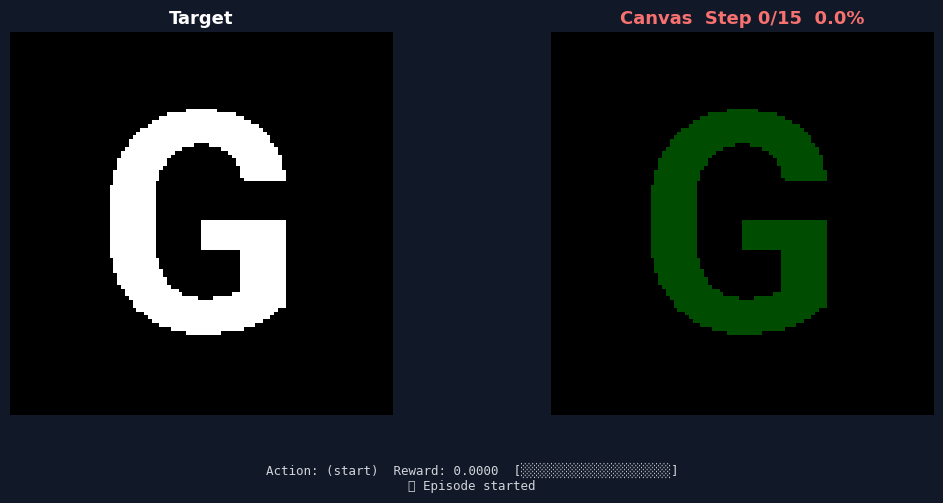

KeyboardInterrupt: 

In [6]:
async def run_episode(task):
    client=OpenAI(base_url=API_BASE_URL,api_key=API_KEY)
    env=LearnHandwritingEnv(base_url=ENV_BASE_URL)
    ep={'task':task,'character':None,'steps':[],'final_score':0.0,'success':False}
    try:
        result=await env.reset(task=task)
        obs=result.observation
        char=obs.target_character
        target=render_target_character(char).astype(float)
        canvas=np.zeros((100,100),dtype=np.int32)
        ep['character']=char
        print(f'Task: {task.upper()}  Character: "{char}"')
        show_step(target,canvas.astype(float),0,'(start)','Episode started',0.0,0.0,False,False)
        history,lm,lw,ink,lr,li=[],0,0,getattr(obs,'ink_remaining',9999),0.0,False
        for step in range(1,MAX_STEPS+1):
            if result.done: break
            bbox=(obs.char_bbox_x1,obs.char_bbox_y1,obs.char_bbox_x2,obs.char_bbox_y2)
            stroke=get_stroke(client,step,char,obs.match_percentage,lm,lw,ink,lr,history,li,bbox)
            action=LearnHandwritingAction(action_type=stroke.action_type,x1=stroke.x1,y1=stroke.y1,
                x2=stroke.x2,y2=stroke.y2,x3=stroke.x3,y3=stroke.y3,
                radius=stroke.radius,rx=stroke.rx,ry=stroke.ry)
            astr=_action_str(stroke)
            canvas=_apply_stroke(canvas,action)
            result=await env.step(action)
            obs=result.observation; reward=result.reward or 0.0
            lm=obs.pixels_matched_this_stroke; lw=getattr(obs,'pixels_wasted_this_stroke',0)
            ink=getattr(obs,'ink_remaining',0); li=getattr(obs,'integrity_violated',False); lr=reward
            cov=obs.match_percentage*100
            show_step(target,canvas.astype(float),step,astr,stroke.reasoning,cov,reward,li,result.done)
            print(f'  Step {step:>2}: {astr:<35} cov={cov:>5.1f}%  r={reward:.4f}{" ⚠️" if li else ""}')
            history.append(f'Step {step}: {astr} cov={cov:.1f}%')
            ep['steps'].append({'step':step,'action':astr,'reasoning':stroke.reasoning,'reward':reward,
                'coverage_pct':cov,'matched_this_step':lm,'wasted_this_step':lw,'ink_remaining':ink,'integrity_violated':li})
    finally:
        try: await env.close()
        except: pass
    score=obs.match_percentage; ep['final_score']=score; ep['success']=score>=0.90
    print(f'\n  {"✅ SUCCESS" if ep["success"] else "❌ FAILED"}  Final: {score:.1%}  Steps: {len(ep["steps"])}/{MAX_STEPS}')
    return ep

episode=asyncio.run(run_episode(TASK))


## Section 3 — 📊 Graphs


In [ ]:
steps=[s['step'] for s in episode['steps']]; cov=[s['coverage_pct'] for s in episode['steps']]
integ=[s['step'] for s in episode['steps'] if s['integrity_violated']]
fig,ax=plt.subplots(figsize=(10,4),facecolor='#111827'); ax.set_facecolor('#1f2937')
ax.plot(steps,cov,marker='o',color='#60a5fa',linewidth=2.5,label='Coverage %')
ax.fill_between(steps,cov,alpha=0.2,color='#60a5fa')
ax.axhline(90,color='#f87171',linestyle='--',linewidth=1.5,label='90% goal')
for s in integ: ax.axvline(s,color='#f87171',alpha=0.6,linewidth=1.2,linestyle=':')
ax.set_title(f'Coverage — {TASK.upper()} "{episode["character"]}"  Final:{episode["final_score"]:.1%}',color='white',fontsize=13,fontweight='bold')
ax.set_xlabel('Step',color='white'); ax.set_ylabel('Coverage (%)',color='white')
ax.tick_params(colors='white'); ax.set_ylim(0,105)
for spine in ax.spines.values(): spine.set_edgecolor('#374151')
ax.legend(); ax.grid(axis='y',alpha=0.2,color='white'); plt.tight_layout()
plt.savefig(f'coverage_{TASK}_{episode["character"]}.png',dpi=150,bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()


In [ ]:
matched=[s['matched_this_step'] for s in episode['steps']]
wasted=[s['wasted_this_step'] for s in episode['steps']]
rewards=[s['reward'] for s in episode['steps']]
x=np.arange(len(steps)); w=0.35
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4),facecolor='#111827')
for ax in (ax1,ax2): ax.set_facecolor('#1f2937'); ax.tick_params(colors='white')
ax1.bar(x-w/2,matched,w,label='Matched',color='#4ade80',alpha=0.85)
ax1.bar(x+w/2,wasted,w,label='Wasted',color='#f87171',alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels([str(s) for s in steps])
total_m,total_w=sum(matched),sum(wasted); eff=total_m/max(total_m+total_w,1)*100
ax1.set_title(f'Pixels/Step  Ink efficiency:{eff:.1f}%',color='white',fontsize=11)
ax1.set_xlabel('Step',color='white'); ax1.legend(); ax1.grid(axis='y',alpha=0.2,color='white')
ax2.bar(steps,rewards,color='#a78bfa',alpha=0.85)
ax2.set_title('Reward per Step',color='white',fontsize=11)
ax2.set_xlabel('Step',color='white'); ax2.grid(axis='y',alpha=0.2,color='white')
for spine in ax1.spines.values(): spine.set_edgecolor('#374151')
for spine in ax2.spines.values(): spine.set_edgecolor('#374151')
plt.tight_layout()
plt.savefig(f'efficiency_{TASK}_{episode["character"]}.png',dpi=150,bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()
print(f'matched={total_m} wasted={total_w} efficiency={eff:.1f}% total_reward={sum(rewards):.4f} score={episode["final_score"]:.1%}')
